17/04/2026: A. Tancetti inspired to plot_spectrum_DBS.py by Peng Shi


IMPORT MODULES

In [13]:
import pyuda
client = pyuda.Client()
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, fft, ndimage
import sys

module_path = "/home/lc4071s/my_scripts"
if module_path not in sys.path:
    sys.path.insert(0, module_path)
    
import library_dbs as dbs

In [14]:
### Setup inputs ------------------------------
shot = 53678 # 53677
t1 = 0.100 # s
t2 = 0.400 # s
do_plot = 1 # set to 1 to show auxiliary plots (set to 0 to skip those)
do_smooth = 1 # set to 1 to smooth the spectrogram (not crucial to see signatures of TAE)

### load raw data (I and Q) for specific shot of interest
system = 'ulcers'
frq = 50 #32.5 # GHz
I_raw, Q_raw, t_raw = dbs.load_raw_dbs_data(shot, system, frq)


Data for UCLA Q-band channel f = 50 GHz ready
Sampling frequency: 9.999999999712443 MHz


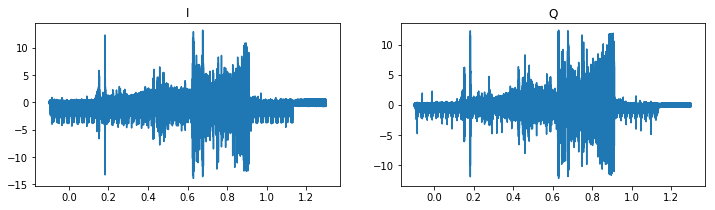

In [15]:
if do_plot:
    fig, axs = plt.subplots(1,2,figsize = (12,3))
    axs[0].plot(t_raw,I_raw)
    axs[1].plot(t_raw,Q_raw)
    axs[0].set_title('I',fontsize = 12)
    axs[1].set_title('Q',fontsize = 12)

SELECT TIME WINDOW AND BUILD COMPLEX SIGNAL

In [16]:
t1_idx = np.where(t_raw >= t1)[0][0]
t2_idx = np.where(t_raw >= t2)[0][0]

I_cac = I_raw[t1_idx:t2_idx]
Q_cac = Q_raw[t1_idx:t2_idx]
time = t_raw[t1_idx:t2_idx]

sig_IQ = I_cac + 1j*Q_cac # I + i Q

COMPUTE INSTANTANEOUS PHASE $\phi(t)$

In order to compute the phase increment between consecutive time points, we make use of the relation: $e^{i[\phi(t_1)-\phi(t_2)]} = e^{i\phi(t_1)} [e^{i\phi(t_2)}]^*$ where the asterisk denotes complex conjugate.

In [17]:
phase_difference = np.zeros(len(sig_IQ))
# Phase-difference calculation: 
# phi - psi = ang(e^{i(phi-psi)}) = ang(e^{i phi} / e^{i psi}) = ang(e^{i phi} * e^{-i psi})
for i in range(len(phase_difference) - 1, 0, -1):
    phase_difference[i] = np.angle(sig_IQ[i] * np.conj(sig_IQ[i - 1]))
# Compute the zeroth phase angle.
phase_difference[0] = np.angle(sig_IQ[0])
# cumulative-sum to get the unwrapped phase.
phase = np.cumsum(phase_difference)


COMPUTE DOPPLER SHIFT AS $d\phi/dt$

In [18]:
dph_dt = np.gradient(phase,time) / (2*np.pi)

COMPUTE SPECTROGRAM USING scipy.signal short time Fourier transform

details for parameters in stft (https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html):

- window: hanning
- nperseg: length of each segment. We feed the NFFT value to nperseg.
- detrend: can be linear or constant. Choosing constant allows to subtract the mean
- return one-sided: False because we have complex-value data
- boundary: with this set to zeros the signal is padded at the FRONT and at the end in order to fit an integer number of NFFT segments.
- nfft: length of FFT used. If None, then FFT length is nperseg

The function wants a number of points for overlap (noverlap), but we conventionally use a fraction. Note that in scipy: 

overlap = None --> noverlap = NFFT//2 

So actually "None" overlap is 50% overlap according to scipy.

In [19]:
NFFT = 1024 * 18 # number of points per segment (nperseg)
my_noverlap = 0 # number of points to overlap between segments

fs = 1 / abs(time[1] - time[0])  # Sampling Rate [Hz]

stft_kwargs = dict(
        window='hann', 
        detrend='constant',
        return_onesided=False,
        boundary=None,
        padded=False,
        nfft=None)

fff, t_spect, spectro = signal.stft(dph_dt, fs=fs, nperseg=NFFT, noverlap=my_noverlap, **stft_kwargs)
print(fff.size, t_spect.size,spectro.shape, NFFT)

18432 162 (18432, 162) 18432


Frequency Correction,

numpy/scipy always give the "standard form" of FFT results, i.e. they give a frequency array from 0 --> Nyquist --> 2*Nyquist. where the negative half of the frequency spectrum lies in indicies between Nyquist --> 2*Nyquist.

In [20]:
f_spect = fft.fftshift(fff)
f_dpdt = f_spect[NFFT // 2 :]

spect_cac = fft.fftshift(spectro, axes=0)
spectro_abs = np.abs(spect_cac)[NFFT // 2 :, :]

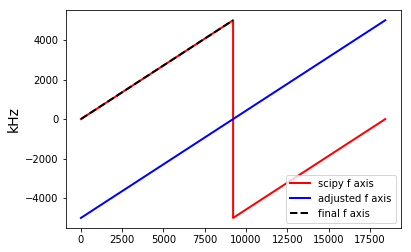

In [21]:
if do_plot:
    plt.figure()
    plt.plot(fff/1e3,'r',linewidth = 2,label = 'scipy f axis')
    plt.plot(f_spect/1e3,'b',linewidth = 2, label = 'adjusted f axis')
    plt.plot(f_dpdt/1e3,'k',linewidth = 2,linestyle = '--',label = 'final f axis')
    plt.ylabel('kHz',fontsize = 14)
    plt.legend()

Time correction

Scipy always starts the time array from zero. Instead we assign the frequency spectra to the midpoint in time corresponding to NFFT.

In [22]:
t_spect += (time[NFFT] + time[0]) / 2
print('segment duration (s): ', time[NFFT]-time[0])

segment duration (s):  0.0018432000000530024


SMOOTHING (actually not necessary to see the signatures of TAE)

In [23]:
if do_smooth:

    f_smooth_dP = 5e3 # Hz
    t_smooth_dP = 1e-3 # s
    spect_dPdT_cac_1 = dbs.smooth_spectrogram(spectro_abs, 
                                                f_dpdt, 
                                                t_spect, 
                                                f_smooth = f_smooth_dP, 
                                                t_smooth = t_smooth_dP)


SPECTROGRAM PLOT

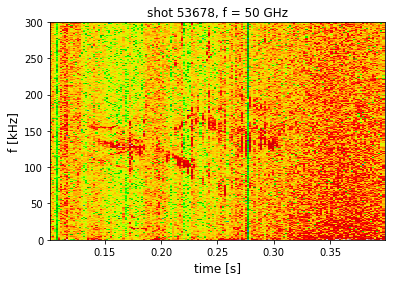

In [24]:
fmax = 3e5
fmax_idx = np.where(f_dpdt >= fmax)[0][0]

fig, axs = plt.subplots(figsize=(6,4))
sp_im = axs.pcolormesh(t_spect, 
                       f_dpdt[:fmax_idx]/1e3, 
                       np.log(spectro_abs[:fmax_idx]), 
                       cmap = 'nipy_spectral')

sp_im.set_clim(1.,12.)
axs.set_xlabel('time [s]',fontsize = 12)
axs.set_ylabel('f [kHz]',fontsize = 12)
axs.set_title(f'shot {shot}, f = {frq} GHz',fontsize = 12)
plt.show()